Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE = True
BITPIX = 16
NAXIS = 2
NAXIS1 = 530
NAXIS2 = 530
(530, 530)
>i2
Minimum: 1507
Maximum: 15752
Mean: 4795.924268422927
Standard deviation: 1848.2526085366376
Median: 4102.0
Mode: 3551


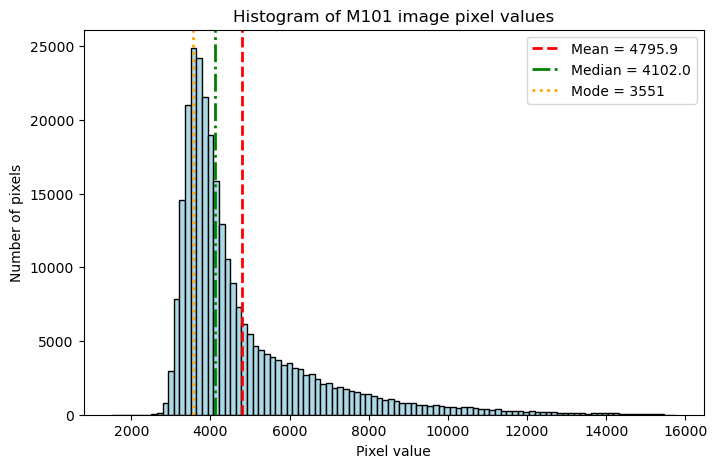

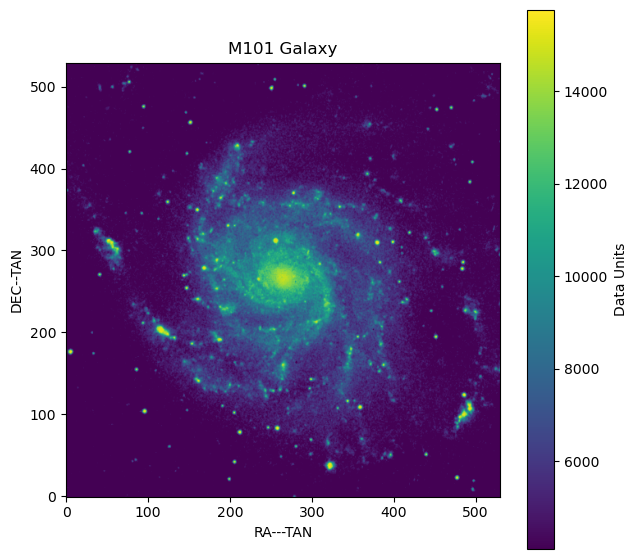

New FITS file 'm101_float.fits' created with floating-point data and BUNIT='Counts'.


 [astropy.io.fits.verify]


In [14]:
from astropy.io import fits

# Open the FITS file
hdul = fits.open('m101.fits')

# Print information about the file structure
hdul.info()

header = hdul[0].header  # primary HDU header

#first 5 keywords
for i, key in enumerate(header.keys()):
    if i < 5:
        print(key, "=", header[key])
#yes they match int16 and bitpix is 16 too

dat = hdul[0].data
print(dat.shape)  #yes it matches, 2D and 530
print(dat.dtype)  #also matches it is 2bytes=16bits

dat_flat = dat.flatten()  #flattens data

import numpy as np
from scipy import stats

print("Minimum:", np.min(dat_flat))
print("Maximum:", np.max(dat_flat))
print("Mean:", np.mean(dat_flat))
print("Standard deviation:", np.std(dat_flat))
print("Median:", np.median(dat_flat))
# Mode
mode_result = stats.mode(dat_flat, keepdims=True)
print("Mode:", mode_result.mode[0])

import matplotlib.pyplot as plt

mean_val = np.mean(dat_flat)
median_val = np.median(dat_flat)
mode_val = stats.mode(dat_flat, keepdims=True).mode[0]

# Create histogram
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(dat_flat, bins=100, color='lightblue', edgecolor='black')

# Add vertical lines
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.1f}')
ax.axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median = {median_val:.1f}')
ax.axvline(mode_val, color='orange', linestyle=':', linewidth=2, label=f'Mode = {mode_val}')

# Labels and legend
ax.set_xlabel('Pixel value')
ax.set_ylabel('Number of pixels')
ax.set_title('Histogram of M101 image pixel values')
ax.legend()

plt.show()

# Convert data to floating point
dat_float = np.asarray(dat, dtype=float)

# Create figure and axes
fig, ax = plt.subplots(figsize=(7,7))

# Display the image
im = ax.imshow(dat_float, origin='lower', cmap='viridis', vmin=median_val)

# Label axes with FITS header keywords
ax.set_xlabel(header['CTYPE1'])
ax.set_ylabel(header['CTYPE2'])

# Add a locatable colorbar with label
cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label('Data Units')

# Add title (optional)
ax.set_title('M101 Galaxy')

plt.show()

# Add new header keyword for data units
header['BUNIT'] = 'Counts'

#new PrimaryHDU with the floating-point data and updated header
hdu_float = fits.PrimaryHDU(data=dat_float, header=header)

# Write the floating-point image to a new FITS file, ignoring invalid header warnings
hdu_float.writeto('m101_float.fits', overwrite=True, output_verify='ignore')

print("New FITS file 'm101_float.fits' created with floating-point data and BUNIT='Counts'.")

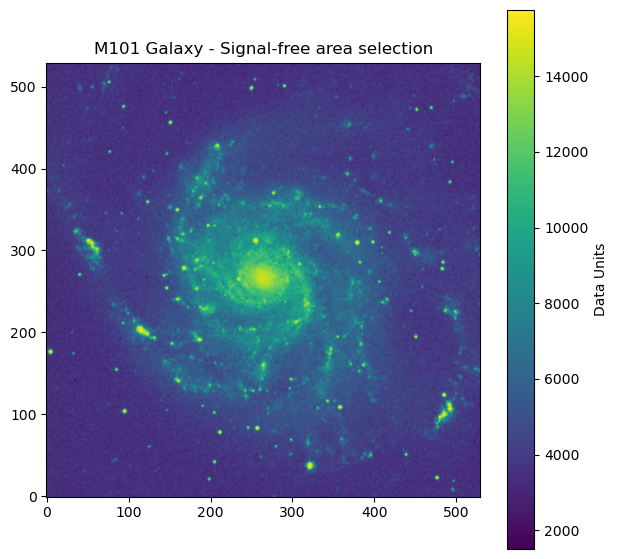

RMS of background area: 3414.025
Mean of background area: 3404.773
Standard deviation of background area: 251.184


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file and get data
hdul = fits.open('m101.fits')
dat = np.asarray(hdul[0].data, dtype=float)
hdul.close()

# Display the image to visually select a signal-free area
plt.figure(figsize=(7,7))
plt.imshow(dat, origin='lower', cmap='viridis')
plt.colorbar(label='Data Units')
plt.title('M101 Galaxy - Signal-free area selection')
plt.show()

# Define 20x20 pixel background area
x_start, x_end = 10, 30
y_start, y_end = 10, 30

bg_area = dat[y_start:y_end, x_start:x_end]

# Compute RMS of the background pixels
rms = np.sqrt(np.mean(bg_area**2))

# Compute mean and standard deviation
mean_bg = np.mean(bg_area)
std_bg = np.std(bg_area)

# Print results
print(f"RMS of background area: {rms:.3f}")
print(f"Mean of background area: {mean_bg:.3f}")
print(f"Standard deviation of background area: {std_bg:.3f}")

In [28]:
from astropy.io import fits
import numpy as np

#open 0 image
hdul = fits.open('noisemap0.fits')
dat0 = hdul[0].data.astype(float)  # convert to float just in case
std_image0 = np.std(dat)
print("Standard deviation of the image:", std_image0)

# Open 1 image
hdul = fits.open('noisemap1.fits')
dat1 = hdul[0].data.astype(float)  
std_image1 = np.std(dat)
print("Standard deviation of the image:", std_image1)

# Open 2 file
hdul = fits.open('noisemap2.fits')
dat2 = hdul[0].data.astype(float)  
std_image2 = np.std(dat)
print("Standard deviation of the image:", std_image2)

#opening the images 
dat1 = fits.getdata('noisemap0.fits').astype(float)
dat2 = fits.getdata('noisemap1.fits').astype(float)
dat3 = fits.getdata('noisemap2.fits').astype(float)

#stacking them along z direction
stacked_z = np.stack([dat1, dat2, dat3])
print("Stacked along z-axis shape:", stacked_z.shape)

#doing the mean
mean_image = np.mean(stacked_z, axis=0)
print("Mean image shape:", mean_image.shape)

#standard deviation
std_all_pixels = np.std(mean_image)
print("Standard deviation of all pixels in the mean image:", std_all_pixels)

mean_val = np.mean(mean_image)
std_manual = np.sqrt(np.sum((mean_image - mean_val)**2) / mean_image.size)
print("Manual standard deviation of all pixels in the mean image:", std_manual)

Standard deviation of the image: 1848.2526085366376
Standard deviation of the image: 1848.2526085366376
Standard deviation of the image: 1848.2526085366376
Stacked along z-axis shape: (3, 893, 891)
Mean image shape: (893, 891)
Standard deviation of all pixels in the mean image: 5.773191380233297
Manual standard deviation of all pixels in the mean image: 5.773191380233297


In [4]:
from astropy.io import fits
import numpy as np
from astropy.table import QTable

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

#difference between reading an image and table
    #image: simple grid of numbers
    #table: list of rows and columns
#diference in data structure
    #image: every spot in grid has same data (all numbers)
    #table: each column can have different type of data (numbers, names)

#create table
data = QTable(data)

#conditions
mask=(
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

#create DATAFLAG
DATAFLAG = np.where(mask, 1, 0)

#add DATAFLAG to table
data['DATAFLAG'] = DATAFLAG

#calculate the absolute magnitude
m=data['GAIAEDR3_PHOT_G_MEAN_MAG']
p=data['GAIAEDR3_PARALLAX']

mask1=((p>0) & (~np.isnan(p)))
p_filtered= np.where(mask1, p, 1000)


abs_M =np.where(mask1, m + 5*np.log10(p_filtered/1000)+5, np.nan)

#add the absolute magnitude to table
abs_M= np.where(DATAFLAG ==0, -1.0, abs_M)
data['ABSOLUTE MAGNITUDE'] = abs_M
print(data)
data.write('APOGEE_update.fits', overwrite=True)

GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG ABSOLUTE MAGNITUDE
----------------- ----------------------- ... -------- ------------------
              nan                     nan ...        0               -1.0
       0.28544167                0.019475 ...        0               -1.0
       0.08209286                0.315081 ...        0               -1.0
        1.2985312              0.00952245 ...        0               -1.0
        1.2985312              0.00952245 ...        1          2.7881622
      -0.02394128               0.0450072 ...        0               -1.0
        1.3863556               0.0175672 ...        1          2.9852724
         2.084405               0.0180373 ...        0               -1.0
       0.12760994               0.0295789 ...        0               -1.0
       0.06958374               0.0354776 ...        0               -1.0
              ...                     ... ...      ...                ...
        0.4197104               0.0149

maximum value: 42489404.0 
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


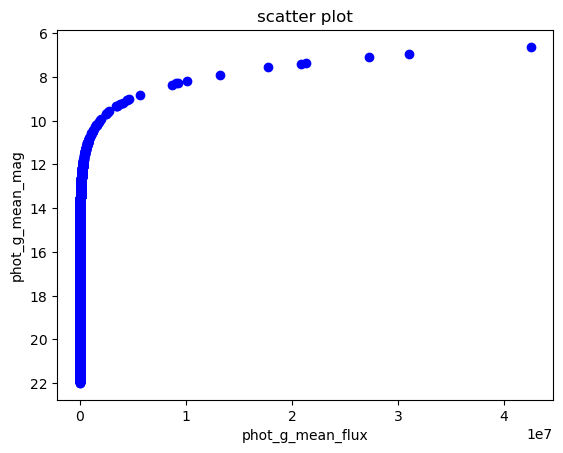

25.68840037029544


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

#create pandas dataframe
pdt = pd.read_csv('gaiaTestData.csv')

#find the maximum value
maximum= pdt.phot_g_mean_flux.max()
print(f"maximum value: {maximum} ")

max_row= pdt[pdt['phot_g_mean_flux']==maximum]

print(max_row)

#sort by column
pdt_sorted=pdt.sort_values(by='phot_g_mean_flux')

#scatter plot
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(pdt_sorted['phot_g_mean_flux'], pdt_sorted['phot_g_mean_mag'], color='blue')
frame.set_xlabel("phot_g_mean_flux")
frame.set_ylabel("phot_g_mean_mag")
frame.set_title('scatter plot')
frame.invert_yaxis()
plt.show()

#calculate
m0= pdt['phot_g_mean_mag']+ 2.5* np.log10(pdt['phot_g_mean_flux'])
m0_avg= m0.mean()
print(m0_avg)

In [3]:
from astroquery.gaia import Gaia
import pandas as pd
from astropy.io import fits

query="""
SELECT TOP 10
    source_id,
    ra,
    dec,
    parallax,
    parallax_error,
    phot_g_mean_mag,
    phot_bp_mean_mag,
    phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/ parallax_error > 5
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""
job = Gaia.launch_job(query)
results = job.get_results()

#create Pandas DataFrame
df_simple = results.to_pandas()

#create output file
results.write('astroquery_gaia.fits', overwrite=True)

#open the file
hdulist = fits.open('astroquery_gaia.fits')
dat = hdulist[1].data
print(dat)


[(4267180339403392768, 286.7169129 ,   0.2761946 , 1.08492386, 0.03343081, 15.244129, 15.942071, 14.419943)
 (6709252873623174016, 276.69119392, -46.10512131, 0.20668183, 0.04010492, 15.840754, 16.380306, 15.151749)
 (4040949706019490560, 265.22936348, -36.35820519, 0.35272487, 0.02966451, 14.802705, 16.118845, 13.680644)
 (4517539583701880064, 284.02566216,  18.40303869, 0.67496243, 0.04000783, 16.073896, 16.652264, 15.347014)
 (1823532754729083392, 300.80580445,  20.60100606, 0.88643505, 0.02005412, 14.375696, 14.782262, 13.795675)
 (3586362911238437248, 171.80987738, -12.08680957, 7.19194838, 0.02249338, 13.987773, 14.809981, 12.990531)
 (2220802729771409024, 320.39987162,  65.73495073, 0.28959899, 0.04491028, 16.704706, 17.259604, 15.978823)
 (5850180760683762688, 205.69113799, -69.2587405 , 0.54108981, 0.08040186, 17.73207 , 18.26916 , 17.014418)
 (2128624652762622080, 294.29627289,  47.56515893, 1.12442278, 0.09253254, 18.168076, 19.113455, 17.192604)
 (5221499841779262720, 128.0

In [8]:
class Fibonacci:
    def __init__(self, N, M):
        # N = how many Fibonacci numbers to generate
        # M = divisor used for filtering
        self.M = M
        self.N = N

    def fibo(self):
        # Generate first N Fibonacci numbers
        fibonacci = []
        a = 0  # first number
        b = 1  # second number

        while len(fibonacci) < self.N:
            fibonacci.append(a)  # add current number
            c = a + b            # next Fibonacci number
            a = b                # shift values
            b = c

        return fibonacci

    def divide(self):
        # Return only Fibonacci numbers divisible by M
        filtered = []
        for i in self.fibo():
            if i % self.M == 0:
                filtered.append(i)
                
        return filtered

# Example 
example = Fibonacci(100, 7)
print(example.fibo())    # prints first 100 Fibonacci numbers
print(example.divide())  # prints those divisible by 7

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269, 2178309, 3524578, 5702887, 9227465, 14930352, 24157817, 39088169, 63245986, 102334155, 165580141, 267914296, 433494437, 701408733, 1134903170, 1836311903, 2971215073, 4807526976, 7778742049, 12586269025, 20365011074, 32951280099, 53316291173, 86267571272, 139583862445, 225851433717, 365435296162, 591286729879, 956722026041, 1548008755920, 2504730781961, 4052739537881, 6557470319842, 10610209857723, 17167680177565, 27777890035288, 44945570212853, 72723460248141, 117669030460994, 190392490709135, 308061521170129, 498454011879264, 806515533049393, 1304969544928657, 2111485077978050, 3416454622906707, 5527939700884757, 8944394323791464, 14472334024676221, 23416728348467685, 37889062373143906, 61305790721611591, 99194853094755497, 160500643816367088, 259695496911122585, 420196140727489673, 679891637638612258, 110008777